# Final Project - ATCNS 
Scalco Riccardo \
Luca Ferrari

## Import vari

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
import torch
from pathlib import Path
from compressai.zoo import cheng2020_anchor
from sklearn.metrics import roc_auc_score, average_precision_score

## Import per script py miei

In [1]:
import sys
sys.path.insert(1, '/kaggle/input/datasets/riccardos02/files-1-py')
import dataset
import detector
import calibration
import compression

## Installazione della libreria compressai

In [5]:
!pip install compressai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.5/444.5 kB 12.1 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 83.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.3/253.3 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 59.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.39.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
kaggle-environments 1.29.3 requires numpy>=2.0, but you have numpy 1.26.4 which is inco

## Parametri generali del progetto

In [ ]:
finestre_da_provare = [16, 24, 32, 48, 64, 96]
soglie_da_provare = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5]

## Impostazione generale dei dataset
Per cambiare dataset basta modificare i parametri della classe definita dalla variabile coppie_valide. Lo script dataset si occuperà in automatico di prendere solo le immagini del dataset che hanno immagine+maschera valida.

In [2]:
DATASET_PATH_CASIA2 = "/kaggle/input/datasets/divg07/casia-20-image-tampering-detection-dataset/CASIA2" 
DATASET_PATH_IMD2020 = "/kaggle/input/datasets/saikotahmed/imd2020/IMD2020"

coppie_valide = dataset.load_and_filter_dataset(
    dataset_root=DATASET_PATH_IMD2020,
    img_folder_name="img",
    mask_folder_name="mask",
    mask_suffix="_mask"
)

# 2. Esegui lo split
train_set, val_set, test_set = dataset.split_dataset(coppie_valide)

# Esempio: stampiamo il path della prima immagine di train
print("Primo elemento del train set:", train_set[0])

Dataset caricato: 2010 coppie valide trovate.
Immagini scartate (maschera assente o file corrotto): 0
Split completato: Train=1407, Val=301, Test=302
Primo elemento del train set: {'image': '/kaggle/input/datasets/saikotahmed/imd2020/IMD2020/img/c9coljf_0.jpg', 'mask': '/kaggle/input/datasets/saikotahmed/imd2020/IMD2020/mask/c9coljf_0_mask.png'}


## Detector
Viene inizializzato il detector. Viene anche fatto un esempio/test con parametri standard per vedere che tutto funzioni

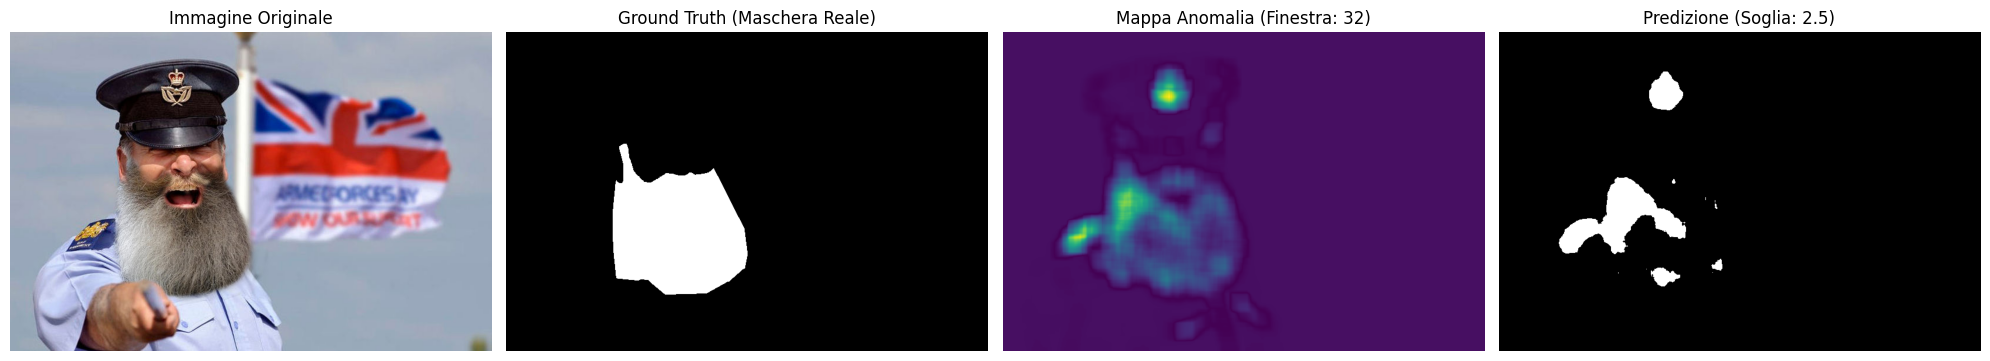

In [3]:
# Inizializziamo il nostro detector (es. finestra=32, soglia=2.5 deviazioni standard)
sb_detector = detector.SpliceBusterDetector(window_size=32, threshold=2.5)

# Prendiamo la prima immagine valida dal train_set che abbiamo creato prima
test_image_path = train_set[0]['image']
test_mask_path = train_set[0]['mask']

# Facciamo la predizione
anomaly_map, pred_mask = sb_detector.predict(test_image_path)

# --- VISUALIZZAZIONE TEST ---
# Carichiamo l'immagine originale e la maschera di ground truth per confronto
img_original = Image.open(test_image_path)
mask_gt = Image.open(test_mask_path)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(img_original)
axes[0].set_title("Immagine Originale")
axes[0].axis('off')

axes[1].imshow(mask_gt, cmap='gray')
axes[1].set_title("Ground Truth (Maschera Reale)")
axes[1].axis('off')

axes[2].imshow(anomaly_map, cmap='viridis')
axes[2].set_title(f"Mappa Anomalia (Finestra: {sb_detector.window_size})")
axes[2].axis('off')

axes[3].imshow(pred_mask, cmap='gray')
axes[3].set_title(f"Predizione (Soglia: {sb_detector.threshold})")
axes[3].axis('off')

plt.tight_layout()
plt.show()

## Detector
Ora viene creato il detector vero e proprio. In questo caso i parametri vengono selezioanti in base ai migliori parametri tramite calibrazione del detector su immagini non compresse.

In [4]:
# 2. Inizializziamo il nostro SpliceBuster
# (i parametri iniziali non contano, verranno sovrascritti dal grid search)
sb = detector.SpliceBusterDetector()

# 3. Lanciamo la calibrazione! 
# Nota: usa val_set (e non train_set) perché l'ottimizzazione si fa sul validation!
# Per un test rapido iniziale, puoi passare solo le prime 10 immagini: val_set[:10]
migliori_parametri, miglior_f1 = calibration.grid_search_calibration(
    val_set=val_set, 
    detector_instance=sb, 
    window_sizes=finestre_da_provare, 
    thresholds=soglie_da_provare
)

# 4. Aggiorniamo il detector con i parametri vincenti
sb.update_parameters(
    new_window_size=migliori_parametri['window_size'],
    new_threshold=migliori_parametri['threshold']
)
print(f"Il detector base è ora calibrato a w={sb.window_size}, t={sb.threshold}")

Inizio calibrazione su 301 immagini...
Elaborate 25/301 immagini...
Elaborate 50/301 immagini...
Elaborate 75/301 immagini...
Elaborate 100/301 immagini...
Elaborate 125/301 immagini...
Elaborate 150/301 immagini...
Elaborate 175/301 immagini...
Elaborate 200/301 immagini...
Elaborate 225/301 immagini...
Elaborate 250/301 immagini...
Elaborate 275/301 immagini...
Elaborate 300/301 immagini...
Elaborate 301/301 immagini...
----------------------------------------
CALIBRAZIONE COMPLETATA!
Migliori parametri trovati: Finestra = 64, Soglia = 1.5
Miglior F1-Score: 0.1395
Il detector base è ora calibrato a w=64, t=1.5


## Compression
Le immagini vengono compresse e messe in tre cartelle separate in base al tipo di compressione. Lavoriamo sul validation set. Le compressioni vengono gestite tramite lo script compression (file py esterno e importato all'inizio). Per modificare quindi il modo in cui vengono compresse le immagini modificare quel file li.

Inoltre il detector viene calibrato tre volte per ogni tipo di compressione, e per ogni tipo vengono trovati i best parameters

In [6]:
# 1. Preparazione delle cartelle di output su Kaggle
WORK_DIR = Path("/kaggle/working/compressed_val")
(WORK_DIR / "jpeg").mkdir(parents=True, exist_ok=True)
(WORK_DIR / "osn").mkdir(parents=True, exist_ok=True)
(WORK_DIR / "jpeg_ai").mkdir(parents=True, exist_ok=True)

# Liste che conterranno le nuove coppie (immagine_compressa, maschera_originale)
val_set_jpeg = []
val_set_osn = []
val_set_jpeg_ai = []

# 2. Setup della GPU e caricamento del modello JPEG-AI
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Dispositivo in uso: {device}")
print("Caricamento modello CompressAI (cheng2020_anchor)...")

# quality=3 è un valore medio standard preaddestrato, perfetto per questo test
jpeg_ai_model = cheng2020_anchor(quality=3, pretrained=True).eval().to(device)

# 3. Ciclo di Compressione
print(f"Inizio compressione di {len(val_set)} immagini del Validation Set...")

for i, item in enumerate(val_set):
    img_path = item['image']
    mask_path = item['mask'] # La maschera rimane identica
    
    filename = Path(img_path).name
    stem = Path(img_path).stem
    
    # Definiamo dove salvare i file
    path_jpeg = str(WORK_DIR / "jpeg" / filename)
    path_osn = str(WORK_DIR / "osn" / filename)
    
    # Per JPEG-AI salviamo in PNG lossless, per non aggiungere artefatti 
    # della codifica standard sopra a quelli della rete neurale
    path_jpeg_ai = str(WORK_DIR / "jpeg_ai" / f"{stem}.png")
    
    # Applichiamo le tre compressioni chiamando il file compression.py
    compression.compress_jpeg(img_path, path_jpeg, quality=75)
    compression.compress_osn(img_path, path_osn, max_size=256, quality=75)
    compression.compress_jpeg_ai(img_path, path_jpeg_ai, jpeg_ai_model, device=device)
    
    # Aggiungiamo i percorsi alle nuove liste
    val_set_jpeg.append({'image': path_jpeg, 'mask': mask_path})
    val_set_osn.append({'image': path_osn, 'mask': mask_path})
    val_set_jpeg_ai.append({'image': path_jpeg_ai, 'mask': mask_path})
    
    if (i + 1) % 10 == 0 or (i + 1) == len(val_set):
        print(f"Compresse {i + 1}/{len(val_set)} immagini...")

print("Compressione completata!")
print("-" * 40)

# 4. Calibrazione dei 3 nuovi Detector specifici
finestre_da_provare = [16, 24, 32, 48, 64, 96]
soglie_da_provare = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5]

# Istanziamo un detector temporaneo da usare per la ricerca
sb_temp = detector.SpliceBusterDetector()

print("--> Calibrazione specifica per JPEG:")
params_jpeg, f1_jpeg = calibration.grid_search_calibration(
    val_set_jpeg, sb_temp, finestre_da_provare, soglie_da_provare
)

print("\n--> Calibrazione specifica per OSN:")
params_osn, f1_osn = calibration.grid_search_calibration(
    val_set_osn, sb_temp, finestre_da_provare, soglie_da_provare
)

print("\n--> Calibrazione specifica per JPEG-AI:")
params_jpeg_ai, f1_jpeg_ai = calibration.grid_search_calibration(
    val_set_jpeg_ai, sb_temp, finestre_da_provare, soglie_da_provare
)

print("-" * 40)
print("RIASSUNTO CALIBRAZIONI SPECIFICHE (Punto 3 completato):")
print(f"JPEG    -> Window: {params_jpeg['window_size']}, Threshold: {params_jpeg['threshold']} (F1: {f1_jpeg:.4f})")
print(f"OSN     -> Window: {params_osn['window_size']}, Threshold: {params_osn['threshold']} (F1: {f1_osn:.4f})")
print(f"JPEG-AI -> Window: {params_jpeg_ai['window_size']}, Threshold: {params_jpeg_ai['threshold']} (F1: {f1_jpeg_ai:.4f})")

Dispositivo in uso: cuda
Caricamento modello CompressAI (cheng2020_anchor)...
Downloading: "https://compressai.s3.amazonaws.com/models/v1/cheng2020-anchor-3-e49be189.pth.tar" to /root/.cache/torch/hub/checkpoints/cheng2020-anchor-3-e49be189.pth.tar


100%|██████████| 49.1M/49.1M [00:01<00:00, 36.6MB/s]


Inizio compressione di 301 immagini del Validation Set...
Compresse 10/301 immagini...
Compresse 20/301 immagini...
Compresse 30/301 immagini...
Compresse 40/301 immagini...
Compresse 50/301 immagini...
Compresse 60/301 immagini...
Compresse 70/301 immagini...
Compresse 80/301 immagini...
Compresse 90/301 immagini...
Compresse 100/301 immagini...
Compresse 110/301 immagini...
Compresse 120/301 immagini...
Compresse 130/301 immagini...
Compresse 140/301 immagini...
Compresse 150/301 immagini...
Compresse 160/301 immagini...
Compresse 170/301 immagini...
Compresse 180/301 immagini...
Compresse 190/301 immagini...
Compresse 200/301 immagini...
Compresse 210/301 immagini...
Compresse 220/301 immagini...
Compresse 230/301 immagini...
Compresse 240/301 immagini...
Compresse 250/301 immagini...
Compresse 260/301 immagini...
Compresse 270/301 immagini...
Compresse 280/301 immagini...
Compresse 290/301 immagini...
Compresse 300/301 immagini...
Compresse 301/301 immagini...
Compressione completa

## Test del detector
Il detector viene testato tramite test set. Prima con parametri trovati tramite immagini non compresse, poi con i parametri adattivi al tipo di compressione.

In [7]:
# 1. PREPARAZIONE DEL TEST SET COMPRESSO
WORK_DIR_TEST = Path("/kaggle/working/compressed_test")
(WORK_DIR_TEST / "jpeg").mkdir(parents=True, exist_ok=True)
(WORK_DIR_TEST / "osn").mkdir(parents=True, exist_ok=True)
(WORK_DIR_TEST / "jpeg_ai").mkdir(parents=True, exist_ok=True)

test_set_jpeg = []
test_set_osn = []
test_set_jpeg_ai = []

print(f"Inizio compressione del TEST SET ({len(test_set)} immagini)...")
for i, item in enumerate(test_set):
    img_path = item['image']
    mask_path = item['mask']
    filename, stem = Path(img_path).name, Path(img_path).stem
    
    path_jpeg = str(WORK_DIR_TEST / "jpeg" / filename)
    path_osn = str(WORK_DIR_TEST / "osn" / filename)
    path_jpeg_ai = str(WORK_DIR_TEST / "jpeg_ai" / f"{stem}.png")
    
    compression.compress_jpeg(img_path, path_jpeg, quality=75)
    compression.compress_osn(img_path, path_osn, max_size=256, quality=75)
    compression.compress_jpeg_ai(img_path, path_jpeg_ai, jpeg_ai_model, device=device)
    
    test_set_jpeg.append({'image': path_jpeg, 'mask': mask_path})
    test_set_osn.append({'image': path_osn, 'mask': mask_path})
    test_set_jpeg_ai.append({'image': path_jpeg_ai, 'mask': mask_path})

print("Compressione Test Set completata!\n" + "-"*50)

# 2. FUNZIONE DI VALUTAZIONE
def evaluate_detector(detector_instance, dataset):
    """
    Calcola le metriche dipendenti dalla soglia (F1, MCC, Prec, Rec) 
    e indipendenti dalla soglia (AUC-ROC, AUC-PR) raccomandate dalla tutor.
    """
    tp_tot, fp_tot, fn_tot, tn_tot = 0, 0, 0, 0
    auc_roc_list = []
    auc_pr_list = []
    
    for item in dataset:
        img_path = item['image']
        mask_path = item['mask']
        
        # Estraiamo sia la mappa continua (per AUC) sia la maschera binaria (per F1)
        anomaly_map, pred_mask = detector_instance.predict(img_path)
        
        # Carichiamo e allineiamo la maschera GT (il fix per CASIA)
        with Image.open(mask_path) as m:
            m = m.convert('L')
            target_size = (pred_mask.shape[1], pred_mask.shape[0])
            if m.size != target_size:
                m = m.resize(target_size, Image.Resampling.NEAREST)
            true_mask = np.array(m) > 127
            
        # 1. Metriche dipendenti dalla soglia (Confusion Matrix GLOBALE)
        p = (pred_mask > 0)
        t = (true_mask > 0)
        
        tp_tot += np.sum(p & t)
        fp_tot += np.sum(p & ~t)
        fn_tot += np.sum(~p & t)
        tn_tot += np.sum(~p & ~t)
        
        # 2. Metriche indipendenti dalla soglia (AUC calcolate PER IMMAGINE)
        t_flat = t.flatten()
        score_flat = anomaly_map.flatten()
        
        # L'AUC può essere calcolata solo se l'immagine ha sia pixel manomessi che originali
        if t_flat.any() and not t_flat.all():
            auc_roc_list.append(roc_auc_score(t_flat, score_flat))
            auc_pr_list.append(average_precision_score(t_flat, score_flat))
            
    # Calcoli finali
    precision = tp_tot / (tp_tot + fp_tot) if (tp_tot + fp_tot) > 0 else 0
    recall = tp_tot / (tp_tot + fn_tot) if (tp_tot + fn_tot) > 0 else 0
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    num = (tp_tot * tn_tot) - (fp_tot * fn_tot)
    den = np.sqrt(float(tp_tot + fp_tot) * float(tp_tot + fn_tot) * float(tn_tot + fp_tot) * float(tn_tot + fn_tot))
    mcc = num / den if den > 0 else 0
    
    mean_auc_roc = np.mean(auc_roc_list) if auc_roc_list else 0
    mean_auc_pr = np.mean(auc_pr_list) if auc_pr_list else 0
    
    return {
        'F1': f1, 'MCC': mcc, 'Precision': precision, 'Recall': recall,
        'AUC-ROC': mean_auc_roc, 'AUC-PR': mean_auc_pr
    }

def print_metrics(name, metrics):
    print(f"{name: <25} | F1: {metrics['F1']:.4f} | AUC-ROC: {metrics['AUC-ROC']:.4f} | AUC-PR: {metrics['AUC-PR']:.4f}")
# 3. IL GRANDE CONFRONTO

# Recuperiamo i parametri base (supponendo li avessi salvati come params_base)
# Sostituisci questi valori con quelli reali stampati alla fine dello step precedente!
BASE_W, BASE_T = migliori_parametri['window_size'], migliori_parametri['threshold'] 

print(f"\n--- TEST DETECTOR BASE (Fisso su w={BASE_W}, t={BASE_T}) ---")
sb.update_parameters(BASE_W, BASE_T)
print_metrics("Original Images", evaluate_detector(sb, test_set))
print_metrics("JPEG Compressed", evaluate_detector(sb, test_set_jpeg))
print_metrics("OSN Compressed", evaluate_detector(sb, test_set_osn))
print_metrics("JPEG-AI Compressed", evaluate_detector(sb, test_set_jpeg_ai))

print("\n--- TEST DETECTOR ADATTIVO (Calibrato su ogni codec) ---")
sb.update_parameters(params_jpeg['window_size'], params_jpeg['threshold'])
print_metrics(f"JPEG (w={sb.window_size}, t={sb.threshold})", evaluate_detector(sb, test_set_jpeg))

sb.update_parameters(params_osn['window_size'], params_osn['threshold'])
print_metrics(f"OSN (w={sb.window_size}, t={sb.threshold})", evaluate_detector(sb, test_set_osn))

sb.update_parameters(params_jpeg_ai['window_size'], params_jpeg_ai['threshold'])
print_metrics(f"JPEG-AI (w={sb.window_size}, t={sb.threshold})", evaluate_detector(sb, test_set_jpeg_ai))

Inizio compressione del TEST SET (302 immagini)...
Compressione Test Set completata!
--------------------------------------------------

--- TEST DETECTOR BASE (Fisso su w=64, t=1.5) ---
Original Images           | F1: 0.1408 | AUC-ROC: 0.5608 | AUC-PR: 0.2161
JPEG Compressed           | F1: 0.1393 | AUC-ROC: 0.5409 | AUC-PR: 0.2060
OSN Compressed            | F1: 0.2024 | AUC-ROC: 0.6266 | AUC-PR: 0.1927
JPEG-AI Compressed        | F1: 0.1486 | AUC-ROC: 0.5284 | AUC-PR: 0.1974

--- TEST DETECTOR ADATTIVO (Calibrato su ogni codec) ---
JPEG (w=96, t=1.0)        | F1: 0.1887 | AUC-ROC: 0.5480 | AUC-PR: 0.2116
OSN (w=96, t=1.5)         | F1: 0.2018 | AUC-ROC: 0.6239 | AUC-PR: 0.1992
JPEG-AI (w=96, t=1.0)     | F1: 0.1739 | AUC-ROC: 0.5436 | AUC-PR: 0.2077


## Plot dei risultati

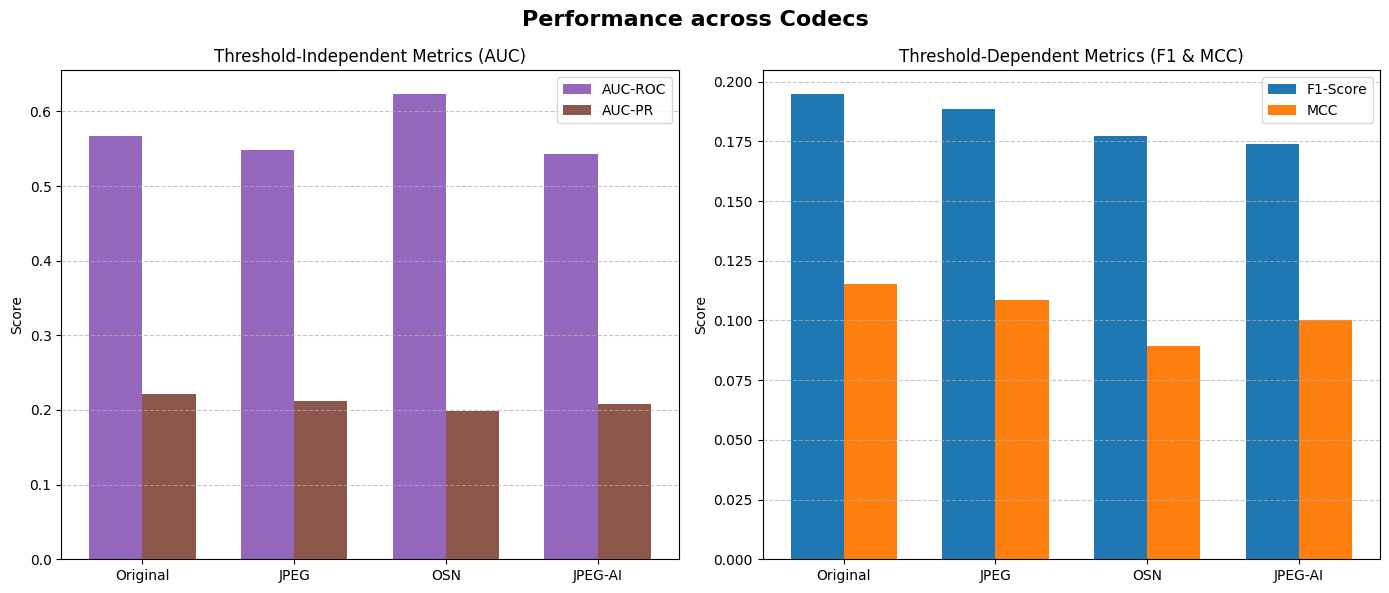

In [8]:
def plot_metrics_comparison(results_dict, title="Performance across Codecs"):
    """
    Genera una figura con due grafici a barre affiancati per separare 
    le metriche AUC da quelle dipendenti dalla soglia (F1, MCC).
    """
    labels = list(results_dict.keys())
    x = np.arange(len(labels))
    width = 0.35  # Barre leggermente più larghe visto che sono solo due per gruppo
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # --- GRAFICO 1: Metriche AUC (Indipendenti dalla soglia) ---
    auc_roc = [results_dict[l]['AUC-ROC'] for l in labels]
    auc_pr = [results_dict[l]['AUC-PR'] for l in labels]
    
    ax1.bar(x - width/2, auc_roc, width, label='AUC-ROC', color='#9467bd')
    ax1.bar(x + width/2, auc_pr, width, label='AUC-PR', color='#8c564b')
    
    ax1.set_ylabel('Score')
    ax1.set_title('Threshold-Independent Metrics (AUC)')
    ax1.set_xticks(x)
    ax1.set_xticklabels(labels)
    ax1.legend()
    ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    # --- GRAFICO 2: Metriche Operative (Dipendenti dalla soglia) ---
    f1 = [results_dict[l]['F1'] for l in labels]
    mcc = [results_dict[l]['MCC'] for l in labels]
    
    ax2.bar(x - width/2, f1, width, label='F1-Score', color='#1f77b4')
    ax2.bar(x + width/2, mcc, width, label='MCC', color='#ff7f0e')
    
    ax2.set_ylabel('Score')
    ax2.set_title('Threshold-Dependent Metrics (F1 & MCC)')
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels)
    ax2.legend()
    ax2.yaxis.grid(True, linestyle='--', alpha=0.7)
    
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig("/kaggle/working/full_metrics_results.png", dpi=300, bbox_inches='tight')
    plt.show()

# --- COME USARLA CON I TUOI RISULTATI ---
# Ricostruiamo al volo il dizionario passando le funzioni di valutazione
# (Questo usa i parametri base w=64, t=1.5 che hai calcolato)
final_results = {
    'Original': evaluate_detector(sb, test_set),
    'JPEG': evaluate_detector(sb, test_set_jpeg),
    'OSN': evaluate_detector(sb, test_set_osn),
    'JPEG-AI': evaluate_detector(sb, test_set_jpeg_ai)
}

plot_metrics_comparison(final_results)

## Ablation study

In [9]:
# ==============================================================================
# BLOCCO 9: ABLATION STUDY (Richiesta della tutor Anastasia)
# Analisi dell'impatto dei singoli parametri (Window vs Threshold)
# ==============================================================================

print("\n" + "="*50)
print("INIZIO ABLATION STUDY: PARAMETRI FISSI VS ADATTIVI")
print("="*50)

# 1. Recuperiamo i parametri base originali (calcolati nel blocco 5)
BASE_W = migliori_parametri['window_size']
BASE_T = migliori_parametri['threshold']

# 2. Definiamo lo spazio di ricerca ampio (uguale al blocco 6)
finestre_da_provare = [16, 24, 32, 48, 64, 96]
soglie_da_provare = [1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0, 3.5]

# 3. Organizziamo i dataset (già caricati in memoria dai blocchi 6 e 7)
datasets = {
    'JPEG': (val_set_jpeg, test_set_jpeg),
    'OSN': (val_set_osn, test_set_osn),
    'JPEG-AI': (val_set_jpeg_ai, test_set_jpeg_ai)
}

# Inizializziamo un detector pulito solo per questo studio
sb_ablation = detector.SpliceBusterDetector()

for codec_name, (val_data, test_data) in datasets.items():
    print(f"\n---> Analisi Ablation per codec: {codec_name} <---")
    
    # ------------------------------------------------------------
    # FASE 1: CALIBRAZIONI PARZIALI (Sul Validation Set compresso)
    # ------------------------------------------------------------
    print("1/3 Cerco solo miglior Threshold (Window bloccata)...")
    params_only_t, _ = calibration.grid_search_calibration(
        val_data, sb_ablation, [BASE_W], soglie_da_provare
    )
    
    print("2/3 Cerco solo miglior Window (Threshold bloccata)...")
    params_only_w, _ = calibration.grid_search_calibration(
        val_data, sb_ablation, finestre_da_provare, [BASE_T]
    )
    
    print("3/3 Cerco miglior coppia (Fully Adaptive)...")
    params_all, _ = calibration.grid_search_calibration(
        val_data, sb_ablation, finestre_da_provare, soglie_da_provare
    )
    
    # ------------------------------------------------------------
    # FASE 2: VALUTAZIONI SUL TEST SET (Usando la funzione del blocco 7)
    # ------------------------------------------------------------
    # A. Fully Fixed (Nessun adattamento)
    sb_ablation.update_parameters(BASE_W, BASE_T)
    res_fixed = evaluate_detector(sb_ablation, test_data)
    
    # B. Adaptive Threshold (Adatto solo la soglia)
    sb_ablation.update_parameters(BASE_W, params_only_t['threshold'])
    res_adapt_t = evaluate_detector(sb_ablation, test_data)
    
    # C. Adaptive Window (Adatto solo la finestra)
    sb_ablation.update_parameters(params_only_w['window_size'], BASE_T)
    res_adapt_w = evaluate_detector(sb_ablation, test_data)
    
    # D. Fully Adaptive (Adatto tutto)
    sb_ablation.update_parameters(params_all['window_size'], params_all['threshold'])
    res_fully = evaluate_detector(sb_ablation, test_data)
    
    # ------------------------------------------------------------
    # FASE 3: STAMPA DEI RISULTATI ABLATION
    # ------------------------------------------------------------
    print(f"\nRISULTATI TEST SET {codec_name}:")
    print_metrics(f"Fixed (w={BASE_W}, t={BASE_T})", res_fixed)
    print_metrics(f"Adapt-T (w={BASE_W}, t={params_only_t['threshold']})", res_adapt_t)
    print_metrics(f"Adapt-W (w={params_only_w['window_size']}, t={BASE_T})", res_adapt_w)
    print_metrics(f"Fully (w={params_all['window_size']}, t={params_all['threshold']})", res_fully)
    print("-" * 50)


INIZIO ABLATION STUDY: PARAMETRI FISSI VS ADATTIVI

---> Analisi Ablation per codec: JPEG <---
1/3 Cerco solo miglior Threshold (Window bloccata)...
Inizio calibrazione su 301 immagini...
Elaborate 25/301 immagini...
Elaborate 50/301 immagini...
Elaborate 75/301 immagini...
Elaborate 100/301 immagini...
Elaborate 125/301 immagini...
Elaborate 150/301 immagini...
Elaborate 175/301 immagini...
Elaborate 200/301 immagini...
Elaborate 225/301 immagini...
Elaborate 250/301 immagini...
Elaborate 275/301 immagini...
Elaborate 300/301 immagini...
Elaborate 301/301 immagini...
----------------------------------------
CALIBRAZIONE COMPLETATA!
Migliori parametri trovati: Finestra = 64, Soglia = 1.0
Miglior F1-Score: 0.1460
2/3 Cerco solo miglior Window (Threshold bloccata)...
Inizio calibrazione su 301 immagini...
Elaborate 25/301 immagini...
Elaborate 50/301 immagini...
Elaborate 75/301 immagini...
Elaborate 100/301 immagini...
Elaborate 125/301 immagini...
Elaborate 150/301 immagini...
Elabora